In [93]:
from difflogic import LogicLayer, GroupSum
import torch


In [94]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [103]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    LogicLayer(4, 4),
    LogicLayer(4, 100),
    GroupSum(k=10, tau=30)
)
model = model.to(device)

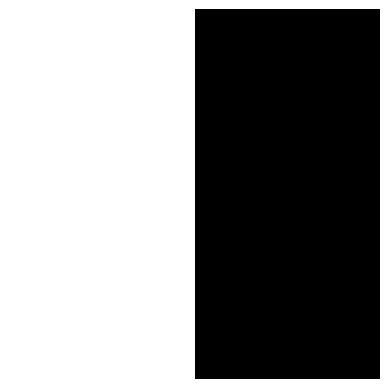

In [96]:
import matplotlib.pyplot as plt

sample_image = [[1,0], [1,0]]
plt.imshow(sample_image, cmap='grey')
plt.axis('off')
plt.show()

During training, the data must be a flattened torch tensor of type float.

You must also ensure that both your model and the data are on the same device*

*e.g. GPU or CPU. If your model is in the CPU, your data must also be in the CPU.

In [97]:
import numpy as np

# convert our image into a numpy array
numpy_image = np.array(sample_image)

# convert our numpy array to have type float
numpy_image_float = image_numpy.astype(float)

# flatten your image
numpy_image_float_flattened = numpy_image_float.flatten().reshape(1, -1)

# make it into a tensor
tensor_image = torch.from_numpy(numpy_image_float_flattened)

# for good measure, ensure it is in the same devide as your model
tensor_image = tensor_image.to(device)

print("original image:\n ", sample_image, "\n")
print("numpy converted image:\n ", numpy_image, "\n")
print("float and numpy image:\n ", numpy_image_float, "\n")
print("float and numpy and flattened image:\n ", numpy_image_float_flattened, "\n")
print("image converted to tensor:\n ", tensor_image, "\n")

original image:
  [[1, 0], [1, 0]] 

numpy converted image:
  [[1 0]
 [1 0]] 

float and numpy image:
  [[1. 0.]
 [1. 0.]] 

float and numpy and flattened image:
  [[1. 0. 1. 0.]] 

image converted to tensor:
  tensor([[1., 0., 1., 0.]], device='cuda:0', dtype=torch.float64) 



In [104]:
model(tensor_image)

tensor([[0.1727, 0.1726, 0.1695, 0.1737, 0.1576, 0.1499, 0.1670, 0.1706, 0.1713,
         0.1726]], device='cuda:0', dtype=torch.float64,
       grad_fn=<DivBackward0>)

Well, the numbers above don't mean anything. To be fair, we have not even trained our model yet, we just initialized it. 

DiffLogic randomly initializes **fixed** connections, meaning the way two nodes connect will remain the same for the entirety of the model.

The only thing the model learns is a *probability distribution* of logic gates (there are 16 possible logic gates) such as "AND", "OR", "NOR"...

In [99]:
model.train()
model(tensor_image)

tensor([[0.1743, 0.1659, 0.1719, 0.1502, 0.1666, 0.1573, 0.1823, 0.1787, 0.1620,
         0.1585]], device='cuda:0', dtype=torch.float64,
       grad_fn=<DivBackward0>)

But... What is the output we got above? Clearly it is 10 numbers as defined in our output layer, but what do they mean?

As of now, nothing, as the model is not set to evaluation. Let's see what happens

In [100]:
model.eval()
model(tensor_image)

tensor([[0.2667, 0.2000, 0.2000, 0.1000, 0.1667, 0.1667, 0.2667, 0.2000, 0.1333,
         0.2000]], device='cuda:0', dtype=torch.float64)

Let's make our own dataset

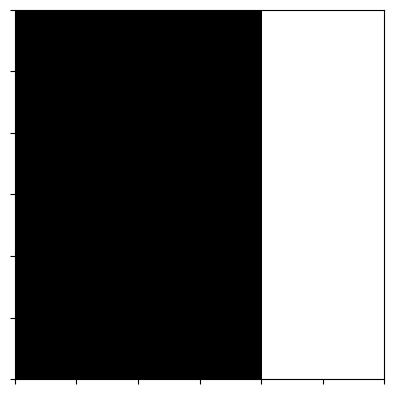

In [88]:
import matplotlib.pyplot as plt

sample_image = [[0,0,1], [0,0,1], [0,0,1]]
sample_image = np.array(sample_image)
plt.imshow(sample_image, cmap='grey')

# just for visibility / presentation
plt.gca().set_xticklabels([])  
plt.gca().set_yticklabels([])  

plt.show()

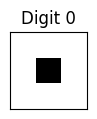

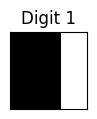

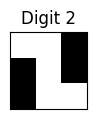

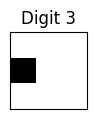

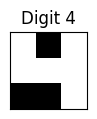

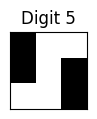

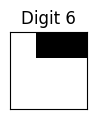

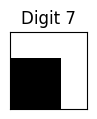

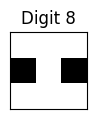

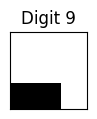

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 3x3 images for each digit 0 to 9
digits = [
    [[1, 1, 1], [1, 0, 1], [1, 1, 1]],  # 0
    [[0, 0, 1], [0, 0, 1], [0, 0, 1]],  # 1
    [[1, 1, 0], [0, 1, 0], [0, 1, 1]],  # 2
    [[1, 1, 1], [0, 1, 1], [1, 1, 1]],  # 3
    [[1, 0, 1], [1, 1, 1], [0, 0, 1]],  # 4
    [[0, 1, 1], [0, 1, 0], [1, 1, 0]],  # 5
    [[1, 0, 0], [1, 1, 1], [1, 1, 1]],  # 6
    [[1, 1, 1], [0, 0, 1], [0, 0, 1]],  # 7
    [[1, 1, 1], [0, 1, 0], [1, 1, 1]],  # 8
    [[1, 1, 1], [1, 1, 1], [0, 0, 1]],  # 9
]

# displaying each digit image
for idx, digit in enumerate(digits):
    plt.figure(figsize=(1, 1))
    plt.imshow(digit, cmap='gray')
    plt.title(f"Digit {idx}")
    
    # removing axis labels for better visibility
    plt.gca().set_xticklabels([])
    plt.gca().set_yticklabels([])
    plt.gca().tick_params(left=False, bottom=False)

    plt.show()

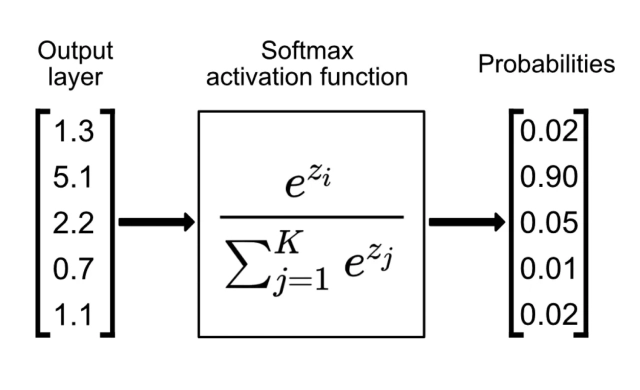

#### Verilog

In [70]:
logic_layers = []
for i in model:
    if 'LogicLayer' in str(i):
        logic_layers.append(i)
        
logic_layers

logic_gate_verilog = {
    "0": "1'b0",
    "A∧B": "({a}) & ({b})",
    "¬(A⇒B)": "({a}) & ~({b})",
    "A": "{a}",
    "¬(B⇒A)": "({b}) & ~({a})",
    "B": "{b}",
    "A⊕B": "({a}) ^ ({b})",
    "A∨B": "({a}) | ({b})",
    "¬(A∨B)": "~(({a}) | ({b}))",
    "¬(A⊕B)": "~(({a}) ^ ({b}))",
    "¬B": "~({b})",
    "B⇒A": "~({b}) | ({a})",
    "¬A": "~({a})",
    "A⇒B": "~({a}) | ({b})",
    "¬(A∧B)": "~(({a}) & ({b}))",
    "1": "1'b1"
}

side = 2 # pixels in one side of the image
N_input = 2 * 2  # number of input dimensions

# converts the learned logic gates to verilog or vhdl 
def generate_verilog(model, filename="logic_network.v"):
    
    N_layers = len(logic_layers)

    # gets number of neurons per layer
    neurons_per_layer = [layer.weights.size()[0] for layer in logic_layers]
    
    # Set the output size to the number of neurons in the last layer
    N_output = neurons_per_layer[-1]
    
    with open(filename, 'w') as file:
        # module declaration
        file.write("module logic_network(\n")
        file.write(f"    input wire [{N_input-1}:0] inputs,\n")
        file.write(f"    output wire [{N_output-1}:0] outputs\n")
        file.write(");\n\n")

        # declares wires for internal layers
        for layer_index in range(N_layers - 1):
            N_neurons = neurons_per_layer[layer_index]
            file.write(f"    wire [{N_neurons -1}:0] layer{layer_index}_outputs;\n")
        file.write("\n")

        logic_operations = list(logic_gate_verilog.keys())

        for layer_index in range(N_layers):
            logic_layer = logic_layers[layer_index]

            # gets input and output indices
            input_indices = logic_layer.indices[0].cpu().numpy()  # first input indices
            output_indices = logic_layer.indices[1].cpu().numpy()  # second input indices

            neuron_gates = [torch.argmax(logic_layer.weights[neuron]).item()
                            for neuron in range(logic_layer.weights.size()[0])]
            connections = {i: (input_indices[i], output_indices[i]) for i in range(len(neuron_gates))}

            N_neurons = neurons_per_layer[layer_index]

            # determines input wires
            if layer_index == 0:
                input_wire_base = "inputs"
            else:
                input_wire_base = f"layer{layer_index -1}_outputs"

            # determines output wires
            if layer_index == N_layers - 1:
                output_wire_base = "outputs"
            else:
                output_wire_base = f"layer{layer_index}_outputs"

            # assign statements for this layer
            for neuron_id in range(N_neurons):
                a_idx, b_idx = connections[neuron_id]

                # maps indices to input wires
                a_wire = f"{input_wire_base}[{a_idx}]"
                b_wire = f"{input_wire_base}[{b_idx}]"

                # gets gate
                gate_op = logic_operations[neuron_gates[neuron_id]]
                gate = logic_gate_verilog[gate_op].format(a=a_wire, b=b_wire)

                # assigns to output wire
                output_wire = f"{output_wire_base}[{neuron_id}]"

                file.write(f"    assign {output_wire} = {gate};\n")

        file.write("endmodule\n")
        print('success')

In [24]:
generate_verilog(model)

success


#### Extracting Learned Connections and Gates

In [75]:
ALL_OPERATIONS = [
    "zero", "and", "not_implies", "a", "not_implied_by", "b", "xor", "or", 
    "not_or", "not_xor", "not_b", "implied_by", "not_a", "implies", "not_and", "one"
]

logic_layers = []
for i in model:
    if 'LogicLayer' in str(i):
        logic_layers.append(i)
        
def get_learned_gates_and_connections(model):
    """
    Extracts the learned logic gates and their connections from a trained DiffLogic model.

    Args:
        model: The trained DiffLogic model.

    Returns:
        learned_gates: A list of dictionaries containing the learned gate and input connections for each layer.
    """
    learned_gates = []

    for layer in logic_layers:
        if isinstance(layer, LogicLayer):
            layer_gates = []
            for neuron_idx in range(layer.weights.size(0)):
                # Get the learned gate by taking the argmax of the weights for the neuron
                gate_op_idx = layer.weights[neuron_idx].argmax().item()
                learned_gate = ALL_OPERATIONS[gate_op_idx]

                # Get the input connections (indices) for the gate
                input_neuron_a = layer.indices[0][neuron_idx].item()
                input_neuron_b = layer.indices[1][neuron_idx].item()

                layer_gates.append({
                    'Gate': learned_gate,
                    'Inputs': (input_neuron_a, input_neuron_b)
                })
            
            learned_gates.append(layer_gates)

    return learned_gates

# usage
learned_gates = get_learned_gates_and_connections(model)

In [74]:
learned_gates

[[{'Gate': 'not_b', 'Inputs': (1, 2)},
  {'Gate': 'and', 'Inputs': (0, 3)},
  {'Gate': 'or', 'Inputs': (2, 3)},
  {'Gate': 'not_implies', 'Inputs': (1, 0)}],
 [{'Gate': 'not_xor', 'Inputs': (3, 3)},
  {'Gate': 'not_implied_by', 'Inputs': (2, 2)},
  {'Gate': 'one', 'Inputs': (2, 1)},
  {'Gate': 'not_and', 'Inputs': (3, 2)},
  {'Gate': 'not_or', 'Inputs': (3, 2)},
  {'Gate': 'implied_by', 'Inputs': (0, 1)},
  {'Gate': 'a', 'Inputs': (1, 1)},
  {'Gate': 'not_implies', 'Inputs': (0, 0)},
  {'Gate': 'a', 'Inputs': (0, 0)},
  {'Gate': 'implies', 'Inputs': (3, 1)}]]

### Graph Visualization

In [71]:
import networkx as nx
import plotly.graph_objects as go

In [77]:
import networkx as nx

def create_neural_network_graph(learned_gates):
    """
    Creates a directed graph for the neural network layers and their connections.

    Args:
        learned_gates (list): A list of lists, where each inner list contains dictionaries 
                              with gate information and input connections for a layer.

    Returns:
        G (networkx.DiGraph): A directed graph representing the neural network.
        positions (dict): A dictionary of node positions for visualization.
    """
    G = nx.DiGraph()  # Create a directed graph
    positions = {}    # Dictionary to store positions for each node
    layer_offset = 0  # Used for positioning the nodes vertically

    # Add nodes and connections for each layer
    for layer_idx, layer in enumerate(learned_gates):
        num_neurons = len(layer)
        for neuron_idx, gate_info in enumerate(layer):
            # Create node name for the current neuron
            node_name = f"L{layer_idx}_N{neuron_idx + 1}"
            G.add_node(node_name, layer=layer_idx)
            positions[node_name] = (layer_idx, -neuron_idx + layer_offset)  # (x, y) coordinates

            # Add edges from the input neurons to the current neuron
            input_neuron_a, input_neuron_b = gate_info['Inputs']
            input_node_1 = f"L{layer_idx - 1}_N{input_neuron_a + 1}" if layer_idx > 0 else f"L0_N{input_neuron_a + 1}"
            input_node_2 = f"L{layer_idx - 1}_N{input_neuron_b + 1}" if layer_idx > 0 else f"L0_N{input_neuron_b + 1}"

            if layer_idx > 0:  # Skip adding edges for the input layer
                G.add_edge(input_node_1, node_name)
                G.add_edge(input_node_2, node_name)

        # Adjust the layer offset for visual separation
        layer_offset += num_neurons

    # Add output layer with 10 nodes (assuming a 10-class classification task)
    num_outputs = 10
    output_layer_idx = len(learned_gates)  # The index for the output layer
    for i in range(num_outputs):
        output_node = f"L{output_layer_idx}_N{i + 1}"
        G.add_node(output_node, layer=output_layer_idx)
        positions[output_node] = (output_layer_idx, -i + layer_offset)

        # Connect the last logic layer to the output layer
        for neuron_idx in range(len(learned_gates[-1])):
            current_node = f"L{output_layer_idx - 1}_N{neuron_idx + 1}"
            G.add_edge(current_node, output_node)

    return G, positions

# Example usage:
# learned_gates is the output from the get_learned_gates_and_connections function
G, positions = create_neural_network_graph(learned_gates)

# Visualize the graph
#nx.draw(G, pos=positions, with_labels=True, node_size=500, font_size=8)
#plt.show()

In [78]:
import plotly.io as pio
import webbrowser
import os

def plot_neural_network(G, positions, filename='neural_network_graph.html'):
    """
    Plots the neural network graph using Plotly and saves it as an HTML file.

    Args:
        G (networkx.DiGraph): The directed graph representing the neural network.
        positions (dict): A dictionary containing the positions for each node in the graph.
        filename (str): The name of the HTML file to save the plot.
    """
    edge_x = []
    edge_y = []

    for edge in G.edges():
        x0, y0 = positions[edge[0]]
        x1, y1 = positions[edge[1]]
        edge_x.append(x0)
        edge_x.append(x1)
        edge_x.append(None)
        edge_y.append(y0)
        edge_y.append(y1)
        edge_y.append(None)

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines')

    node_x = []
    node_y = []
    node_text = []

    for node in G.nodes():
        x, y = positions[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(node)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        marker=dict(
            showscale=True,
            colorscale='YlGnBu',
            size=10,
            colorbar=dict(
                thickness=15,
                title='Neuron Activation',
                xanchor='left',
                titleside='right'
            ),
            line_width=2),
        text=node_text
    )

    fig = go.Figure(data=[edge_trace, node_trace],
                    layout=go.Layout(
                        title='<br>Neural Network Graph',
                        titlefont_size=16,
                        showlegend=False,
                        hovermode='closest',
                        margin=dict(b=0, l=0, r=0, t=0),
                        annotations=[dict(
                            text="Neural Network Structure",
                            showarrow=False,
                            xref="paper", yref="paper",
                            x=0.005, y=-0.002)],
                        xaxis=dict(showgrid=False, zeroline=False),
                        yaxis=dict(showgrid=False, zeroline=False))
                    )

    # Save figure as an HTML file
    pio.write_html(fig, file=filename)

    # Open the HTML file in a new browser tab
    full_path = os.path.abspath(filename)
    webbrowser.open(f'file://{full_path}')

In [79]:
plot_neural_network(G, positions)